**Day 1 – Project Setup & Dataset Selection**

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [18]:
try:
    df=pd.read_csv('student_performance_dataset.csv')
    print('File loaded successfully...')
except:
    print('File not found')

File loaded successfully...


In [19]:
df

,Student_ID,Gender,Study_Hours_per_Week,Attendance_Rate,Past_Exam_Scores,Parental_Education_Level,Internet_Access_at_Home,Extracurricular_Activities,Final_Exam_Score,Pass_Fail
0,S147,Male,31,68.267841,86,High School,Yes,Yes,63,Pass
1,S136,Male,16,78.222927,73,PhD,No,No,50,Fail
2,S209,Female,21,87.525096,74,PhD,Yes,No,55,Fail
3,S458,Female,27,92.076483,99,Bachelors,No,No,65,Pass
4,S078,Female,37,98.655517,63,Masters,No,Yes,70,Pass
...,...,...,...,...,...,...,...,...,...,...
703,S492,Male,14,84.658761,78,PhD,Yes,No,50,Fail
704,S301,Male,35,60.278990,83,Masters,No,No,62,Pass
705,S473,Male,25,98.384969,75,Bachelors,Yes,No,57,Fail
706,S307,Female,21,96.148012,84,Bachelors,Yes,No,65,Pass


In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 708 entries, 0 to 707
Data columns (total 10 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Student_ID                  708 non-null    object 
 1   Gender                      708 non-null    object 
 2   Study_Hours_per_Week        708 non-null    int64  
 3   Attendance_Rate             708 non-null    float64
 4   Past_Exam_Scores            708 non-null    int64  
 5   Parental_Education_Level    708 non-null    object 
 6   Internet_Access_at_Home     708 non-null    object 
 7   Extracurricular_Activities  708 non-null    object 
 8   Final_Exam_Score            708 non-null    int64  
 9   Pass_Fail                   708 non-null    object 
dtypes: float64(1), int64(3), object(6)
memory usage: 55.4+ KB


**Day 2 – Data Exploration**

In [21]:
df.isnull().sum()
#no null values in 

Student_ID                    0
Gender                        0
Study_Hours_per_Week          0
Attendance_Rate               0
Past_Exam_Scores              0
Parental_Education_Level      0
Internet_Access_at_Home       0
Extracurricular_Activities    0
Final_Exam_Score              0
Pass_Fail                     0
dtype: int64

In [22]:
df.describe()

,Study_Hours_per_Week,Attendance_Rate,Past_Exam_Scores,Final_Exam_Score
count,708.000000,708.000000,708.000000,708.000000
mean,26.132768,78.107722,77.871469,58.771186
std,8.877727,13.802802,14.402739,6.705877
min,10.000000,50.116970,50.000000,50.000000
25%,19.000000,67.550094,65.000000,52.000000
50%,27.000000,79.363046,79.000000,59.500000
75%,34.000000,89.504232,91.000000,64.000000
max,39.000000,99.967675,100.000000,77.000000


here the features Study_Hours_per_Week having mean 26 and median 27 is left skewed
Attendance_Rate:- having mean 78 and median 79 is left skewed
Past exam score :- having mean 77 and median 79 is higly left skewed 
final exam score:- having mean 58 and mediah 59 is left skewed 

In [23]:
df['Pass_Fail']=df['Pass_Fail'].map({'Pass':1,'Fail':0})

In [24]:
from scipy.stats import skew, kurtosis

num_df = df.select_dtypes(include=['int64', 'float64'])

In [25]:
# ---- Mean ----
mean_values = num_df.mean()

# ---- Median ----
median_values = num_df.median()

# ---- Standard Deviation ----
std_values = num_df.std()

# ---- Skewness ----
skewness_values = num_df.apply(skew)

# ---- Kurtosis ----
kurtosis_values = num_df.apply(kurtosis)

# Display results
print("MEAN:\n", mean_values)
print("\nMEDIAN:\n", median_values)
print("\nSTANDARD DEVIATION:\n", std_values)
print("\nSKEWNESS:\n", skewness_values)
print("\nKURTOSIS:\n", kurtosis_values)

MEAN:
 Study_Hours_per_Week    26.132768
Attendance_Rate         78.107722
Past_Exam_Scores        77.871469
Final_Exam_Score        58.771186
Pass_Fail                0.500000
dtype: float64

MEDIAN:
 Study_Hours_per_Week    27.000000
Attendance_Rate         79.363046
Past_Exam_Scores        79.000000
Final_Exam_Score        59.500000
Pass_Fail                0.500000
dtype: float64

STANDARD DEVIATION:
 Study_Hours_per_Week     8.877727
Attendance_Rate         13.802802
Past_Exam_Scores        14.402739
Final_Exam_Score         6.705877
Pass_Fail                0.500353
dtype: float64

SKEWNESS:
 Study_Hours_per_Week   -0.239362
Attendance_Rate        -0.329260
Past_Exam_Scores       -0.191614
Final_Exam_Score        0.157562
Pass_Fail               0.000000
dtype: float64

KURTOSIS:
 Study_Hours_per_Week   -1.193466
Attendance_Rate        -0.968259
Past_Exam_Scores       -1.177304
Final_Exam_Score       -0.992264
Pass_Fail              -2.000000
dtype: float64


1. Study_Hours_per_week

Mean (26.13) < Median (27)
Distribution is slightly left skewed

Skewness = −0.239
 Confirms mild negative skewness

Standard Deviation = 8.87
Moderate variation in weekly study hours

Inference:
Most students study around 27 hours/week, with a few students studying less, causing slight left skewness.

2. Attendance_Rate

Mean (78.11) < Median (79.36)
Left skewed distribution

Skewness = −0.968
Moderate negative skewness

Standard Deviation = 13.80
Attendance varies significantly among students

Inference:
Majority of students have high attendance, while fewer students with low attendance pull the distribution to the left.

3. Past_Exam_Scores

Mean (77.87) < Median (79)
Left skewed

Skewness = −1.177
Strong negative skewness

Standard Deviation = 14.40
Wide spread in past exam performance

Inference:
Most students scored high marks previously, while a small number of low scorers create a strong left skew.

4. Final_Exam_Score

Mean (58.77) < Median (59.5)
Left skewed

Skewness = −0.992
Moderate to strong negative skewness

Standard Deviation = 6.71
Scores are relatively consistent

Inference:
Final exam scores are more consistent than past scores, with most students scoring near the median.

In [26]:
#categorical column
cat_col=df.select_dtypes(include='object').columns

df.duplicated().sum()

df.drop_duplicates(inplace=True)

df.duplicated().sum()

np.int64(0)

**Day 3 – Data Visualization (EDA)**

<Axes: xlabel='Pass_Fail', ylabel='count'>

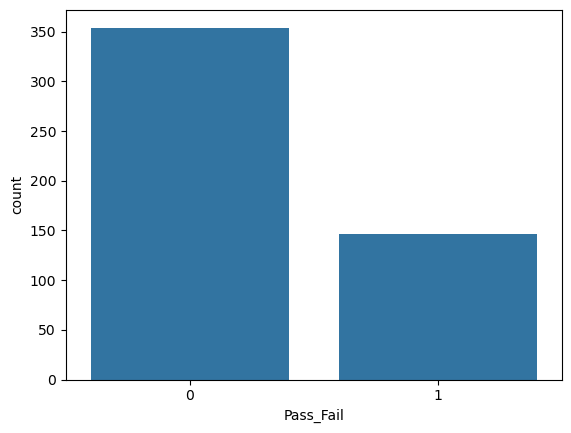

In [27]:
sns.countplot(df,x=df['Pass_Fail'])

the class is highly imbalace

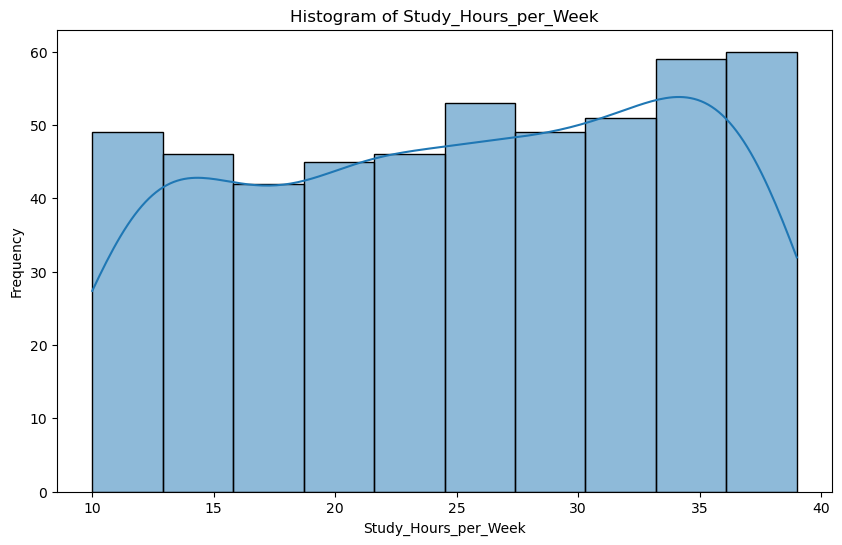

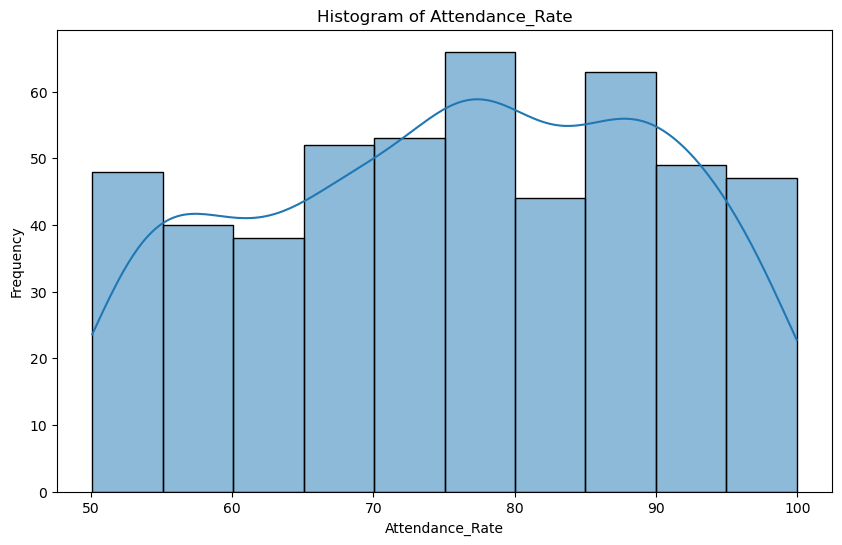

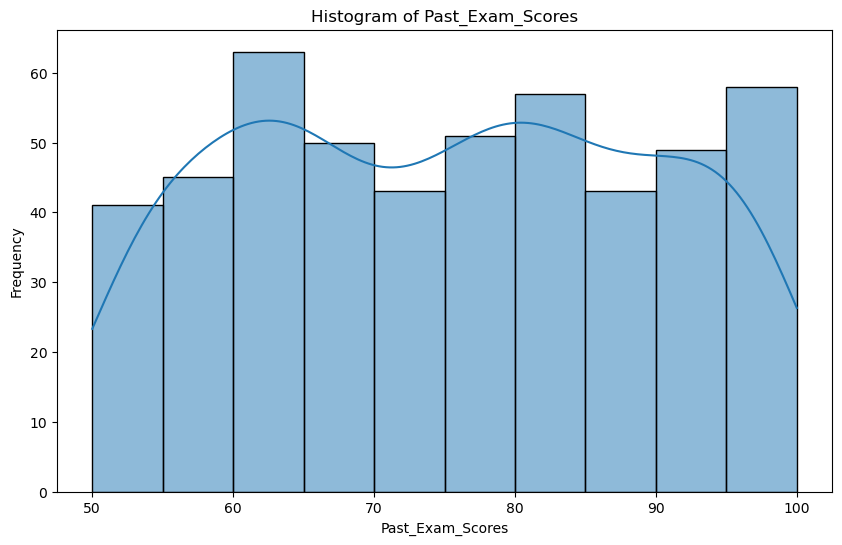

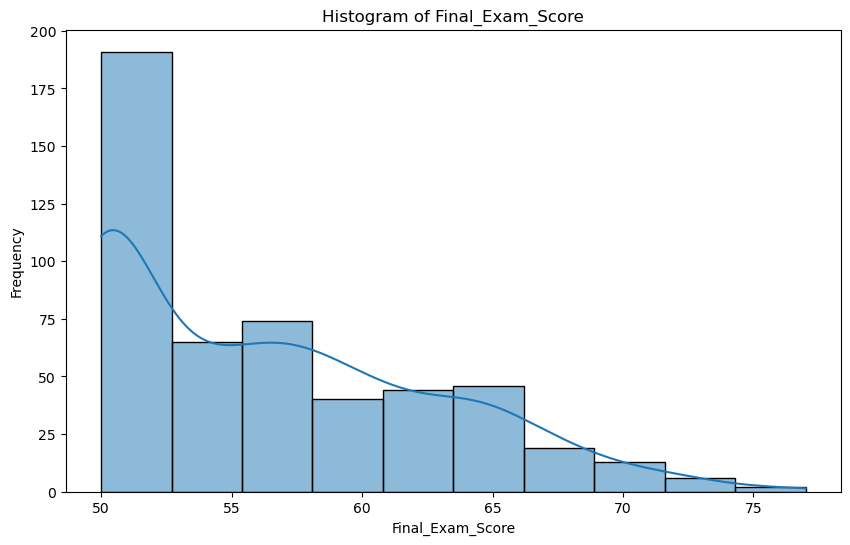

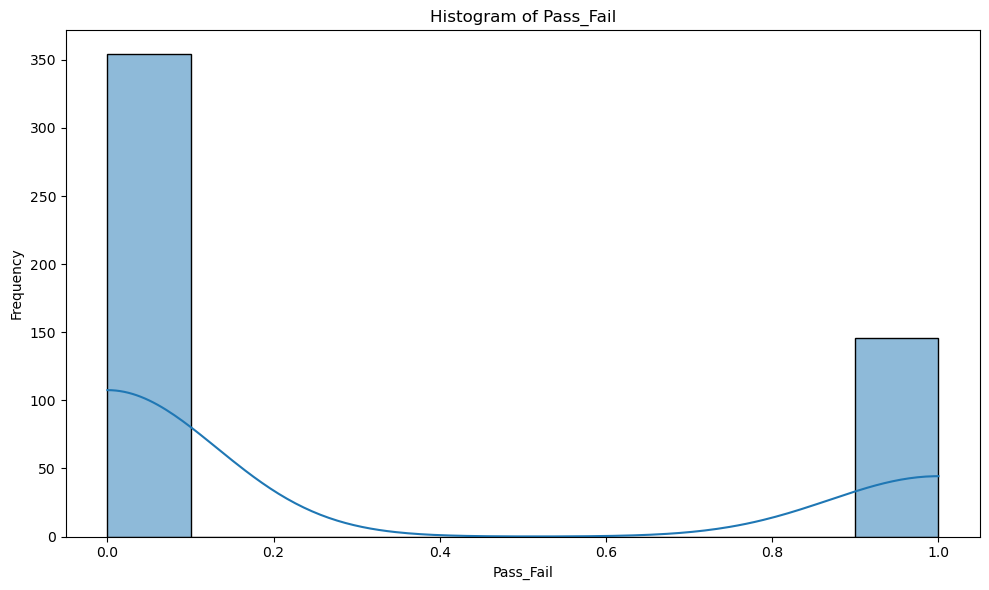

In [28]:
# histogram 


for col in num_df:
    plt.figure(figsize=(10, 6))
    sns.histplot(x=df[col], kde=True)
    plt.title(f'Histogram of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()


All numerical features show negative (left) skewness, indicating that most students have higher study hours, attendance, and exam scores, while a few low values create a left-side tail. The data is moderately spread and suitable for student performance prediction.

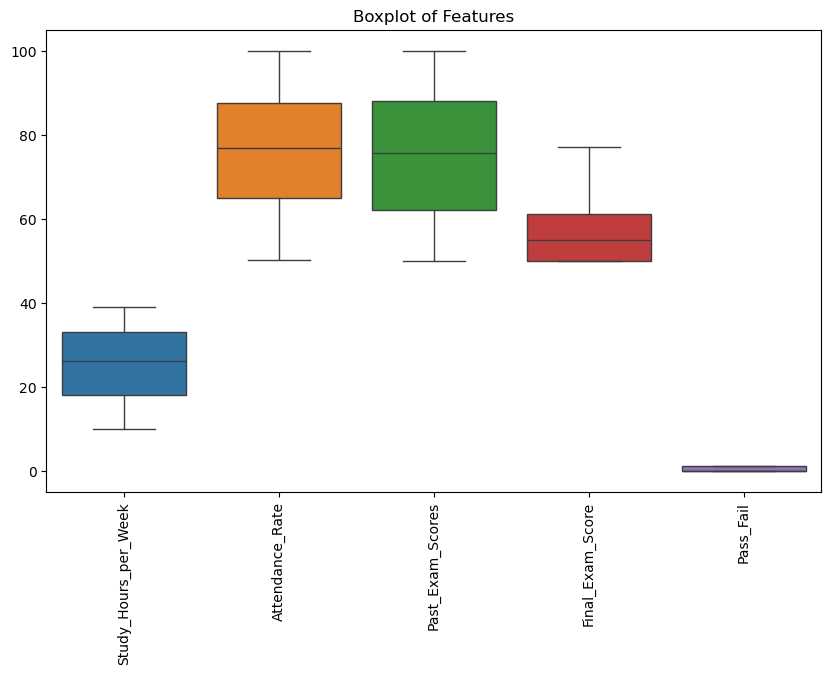

In [29]:
# boxplot
plt.figure(figsize=(10, 6))
sns.boxplot(data=df)
plt.xticks(rotation=90)
plt.title("Boxplot of Features")
plt.show()


NO outliers are present this dataset 

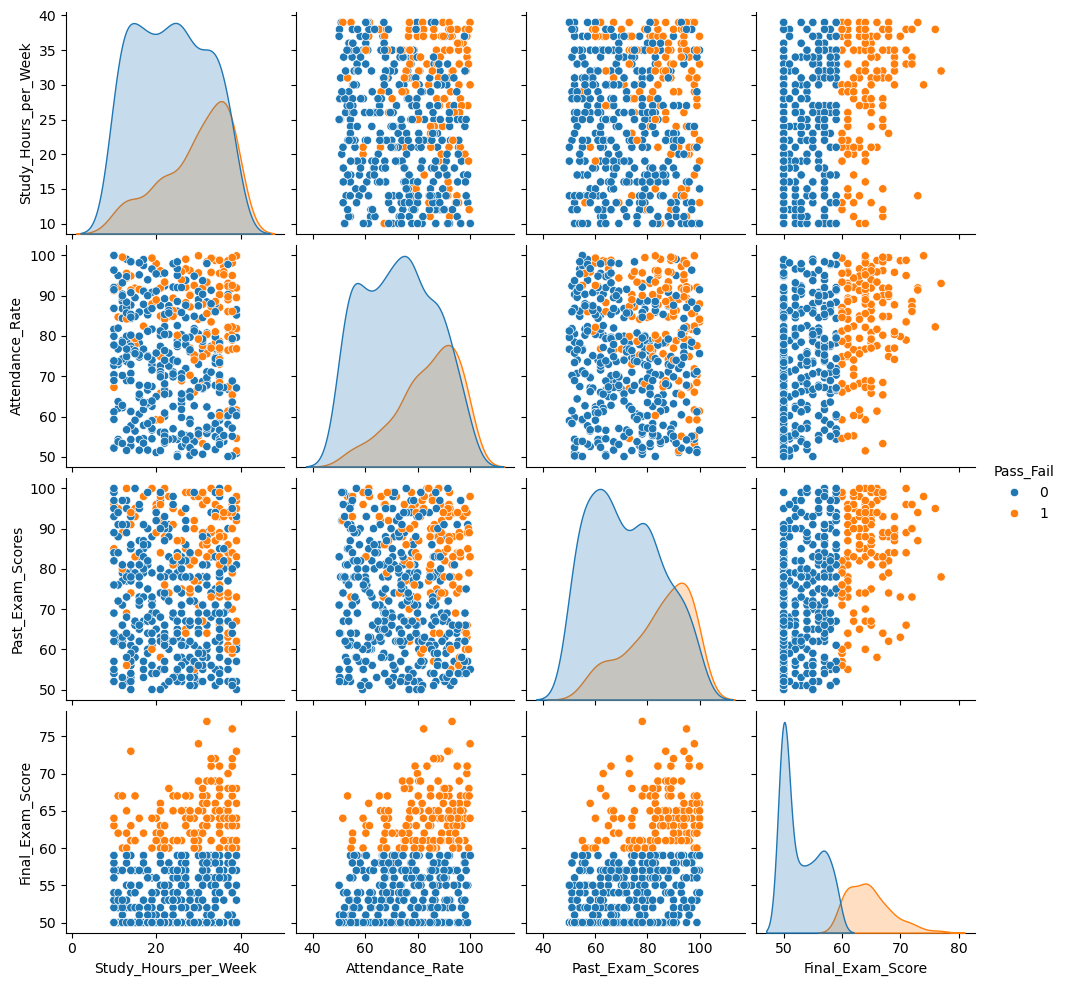

In [30]:
sns.pairplot(df,hue='Pass_Fail')

The pairplot shows positive relationships between student effort indicators and final exam performance, with past exam scores being the strongest predictor.

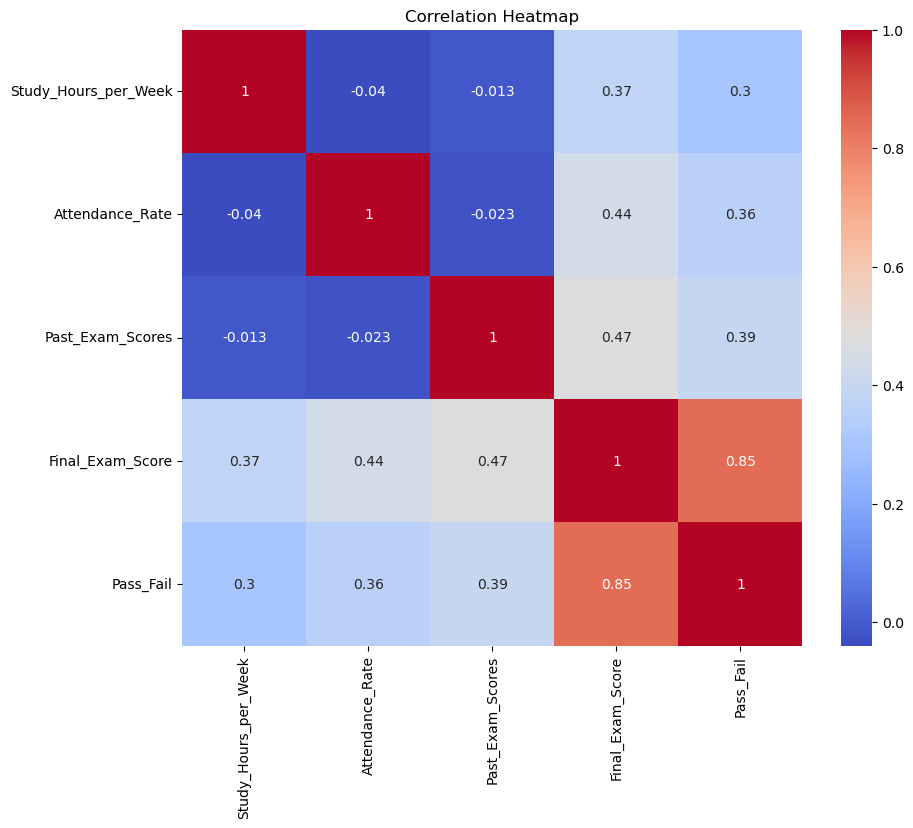

In [31]:
# heatmap
plt.figure(figsize=(10, 8))
corr=df.select_dtypes(include='number').corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

The heatmap shows that Final Exam Score strongly determines Pass/Fail, while Past Exam Scores, Attendance, and Study Hours have moderate positive influence.

In [32]:
# droping the unnecessary column
df2=df.drop(columns=['Student_ID', 'Gender'])
df2.head()

,Study_Hours_per_Week,Attendance_Rate,Past_Exam_Scores,Parental_Education_Level,Internet_Access_at_Home,Extracurricular_Activities,Final_Exam_Score,Pass_Fail
0,31,68.267841,86,High School,Yes,Yes,63,1
1,16,78.222927,73,PhD,No,No,50,0
2,21,87.525096,74,PhD,Yes,No,55,0
3,27,92.076483,99,Bachelors,No,No,65,1
4,37,98.655517,63,Masters,No,Yes,70,1


From the EDA we can see that the most important features for our model is :
Past_Exam_Scores,
Attendance_Rate,
Study_Hours_per_Week.

**Day 4 – Data Preprocessing**

In [33]:
# Now spliting the input and output feature
X = df[['Study_Hours_per_Week', 'Attendance_Rate', 'Past_Exam_Scores', 'Final_Exam_Score']]
y = df['Pass_Fail']


In [34]:
# Train Test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.2,random_state=42,stratify=y)

In [35]:
# Scaling the numeric features 
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [36]:
# our class is imbalance so lets balance it usig SMOTE
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)


**Day 5 – Model Selection & Training**

LogisticRegerssion

In [37]:
# logistic regression
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(random_state=42)
model.fit(X_train_sm, y_train_sm)


LogisticRegression(random_state=42)

In [38]:
y_pred = model.predict(X_test)


In [39]:
# modle evaluation
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

y_prob = model.predict_proba(X_test)[:,1]
print("ROC-AUC:", roc_auc_score(y_test, y_prob))


[[69  2]
 [ 0 29]]
              precision    recall  f1-score   support

           0       1.00      0.97      0.99        71
           1       0.94      1.00      0.97        29

    accuracy                           0.98       100
   macro avg       0.97      0.99      0.98       100
weighted avg       0.98      0.98      0.98       100

ROC-AUC: 1.0


The Logistic Regression model trained using SMOTE effectively handled class imbalance and achieved excellent performance. The model demonstrates high precision, recall, and F1-score for both classes, with an ROC-AUC of 1.0, indicating strong class separability and reliable predictive capability.

here Randomforest is overfitted so we can use it 

In [40]:
# using SVM

from sklearn.svm import SVC

svm = SVC(
    kernel='rbf',
    class_weight='balanced',
    probability=True,
    random_state=42
)

svm.fit(X_train_sm, y_train_sm)

y_pred_svm = svm.predict(X_test)
y_prob_svm = svm.predict_proba(X_test)[:, 1]

print("SVM Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_svm))

print("\nSVM Classification Report:")
print(classification_report(y_test, y_pred_svm))

print("SVM ROC-AUC:", roc_auc_score(y_test, y_prob_svm))


SVM Confusion Matrix:
[[68  3]
 [ 1 28]]

SVM Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.96      0.97        71
           1       0.90      0.97      0.93        29

    accuracy                           0.96       100
   macro avg       0.94      0.96      0.95       100
weighted avg       0.96      0.96      0.96       100

SVM ROC-AUC: 0.9985429820301117


** Final MOdel Selection**
Logistic Regression is the better choice because:

Higher accuracy & F1-score

Perfect recall for Pass class

D**ay 7 – Improving Model Performance**

In [41]:
# Using GridSearchCV 

from sklearn.svm import SVC

param_grid = {
    'C': [0.1, 1, 10, 100],
    'kernel': ['linear', 'rbf'],
    'gamma': ['scale', 0.01, 0.1, 1]
}


In [42]:
from sklearn.model_selection import GridSearchCV

svm = SVC(
    class_weight='balanced',
    probability=True,
    random_state=42
)

grid = GridSearchCV(
    svm,
    param_grid,
    scoring='f1',
    cv=5,
    n_jobs=-1
)

grid.fit(X_train_sm, y_train_sm)


GridSearchCV(cv=5,
             estimator=SVC(class_weight='balanced', probability=True,
                           random_state=42),
             n_jobs=-1,
             param_grid={'C': [0.1, 1, 10, 100],
                         'gamma': ['scale', 0.01, 0.1, 1],
                         'kernel': ['linear', 'rbf']},
             scoring='f1')

In [43]:
print("Best Parameters:", grid.best_params_)
print("Best CV F1 Score:", grid.best_score_)

Best Parameters: {'C': 10, 'gamma': 'scale', 'kernel': 'linear'}
Best CV F1 Score: 1.0


In [44]:
# traing best SVM model
best_svm = grid.best_estimator_

y_pred_best = best_svm.predict(X_test)
y_prob_best = best_svm.predict_proba(X_test)[:, 1]

In [45]:
# Evaluating model
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_best))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_best))

print("ROC-AUC:", roc_auc_score(y_test, y_prob_best))


Confusion Matrix:
[[71  0]
 [ 0 29]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        71
           1       1.00      1.00      1.00        29

    accuracy                           1.00       100
   macro avg       1.00      1.00      1.00       100
weighted avg       1.00      1.00      1.00       100

ROC-AUC: 1.0


Now our model after hyper parameter tuning giving acuracy 1 so now we have to do Cross validation on full dataset

In [46]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    best_svm,
    X,
    y,
    cv=5,
    scoring='f1'
)

print("Cross-Validation F1 Scores:", scores)
print("Mean F1 Score:", scores.mean())


Cross-Validation F1 Scores: [1. 1. 1. 1. 1.]
Mean F1 Score: 1.0


F1 score is greater than 95 mans our model is strong

**Saving the model using joblib**

In [47]:
import joblib


joblib.dump(best_svm, "svm_pass_fail_model.pkl",compress=3)
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']